<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Graphene_Electronic_Band_Structure_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

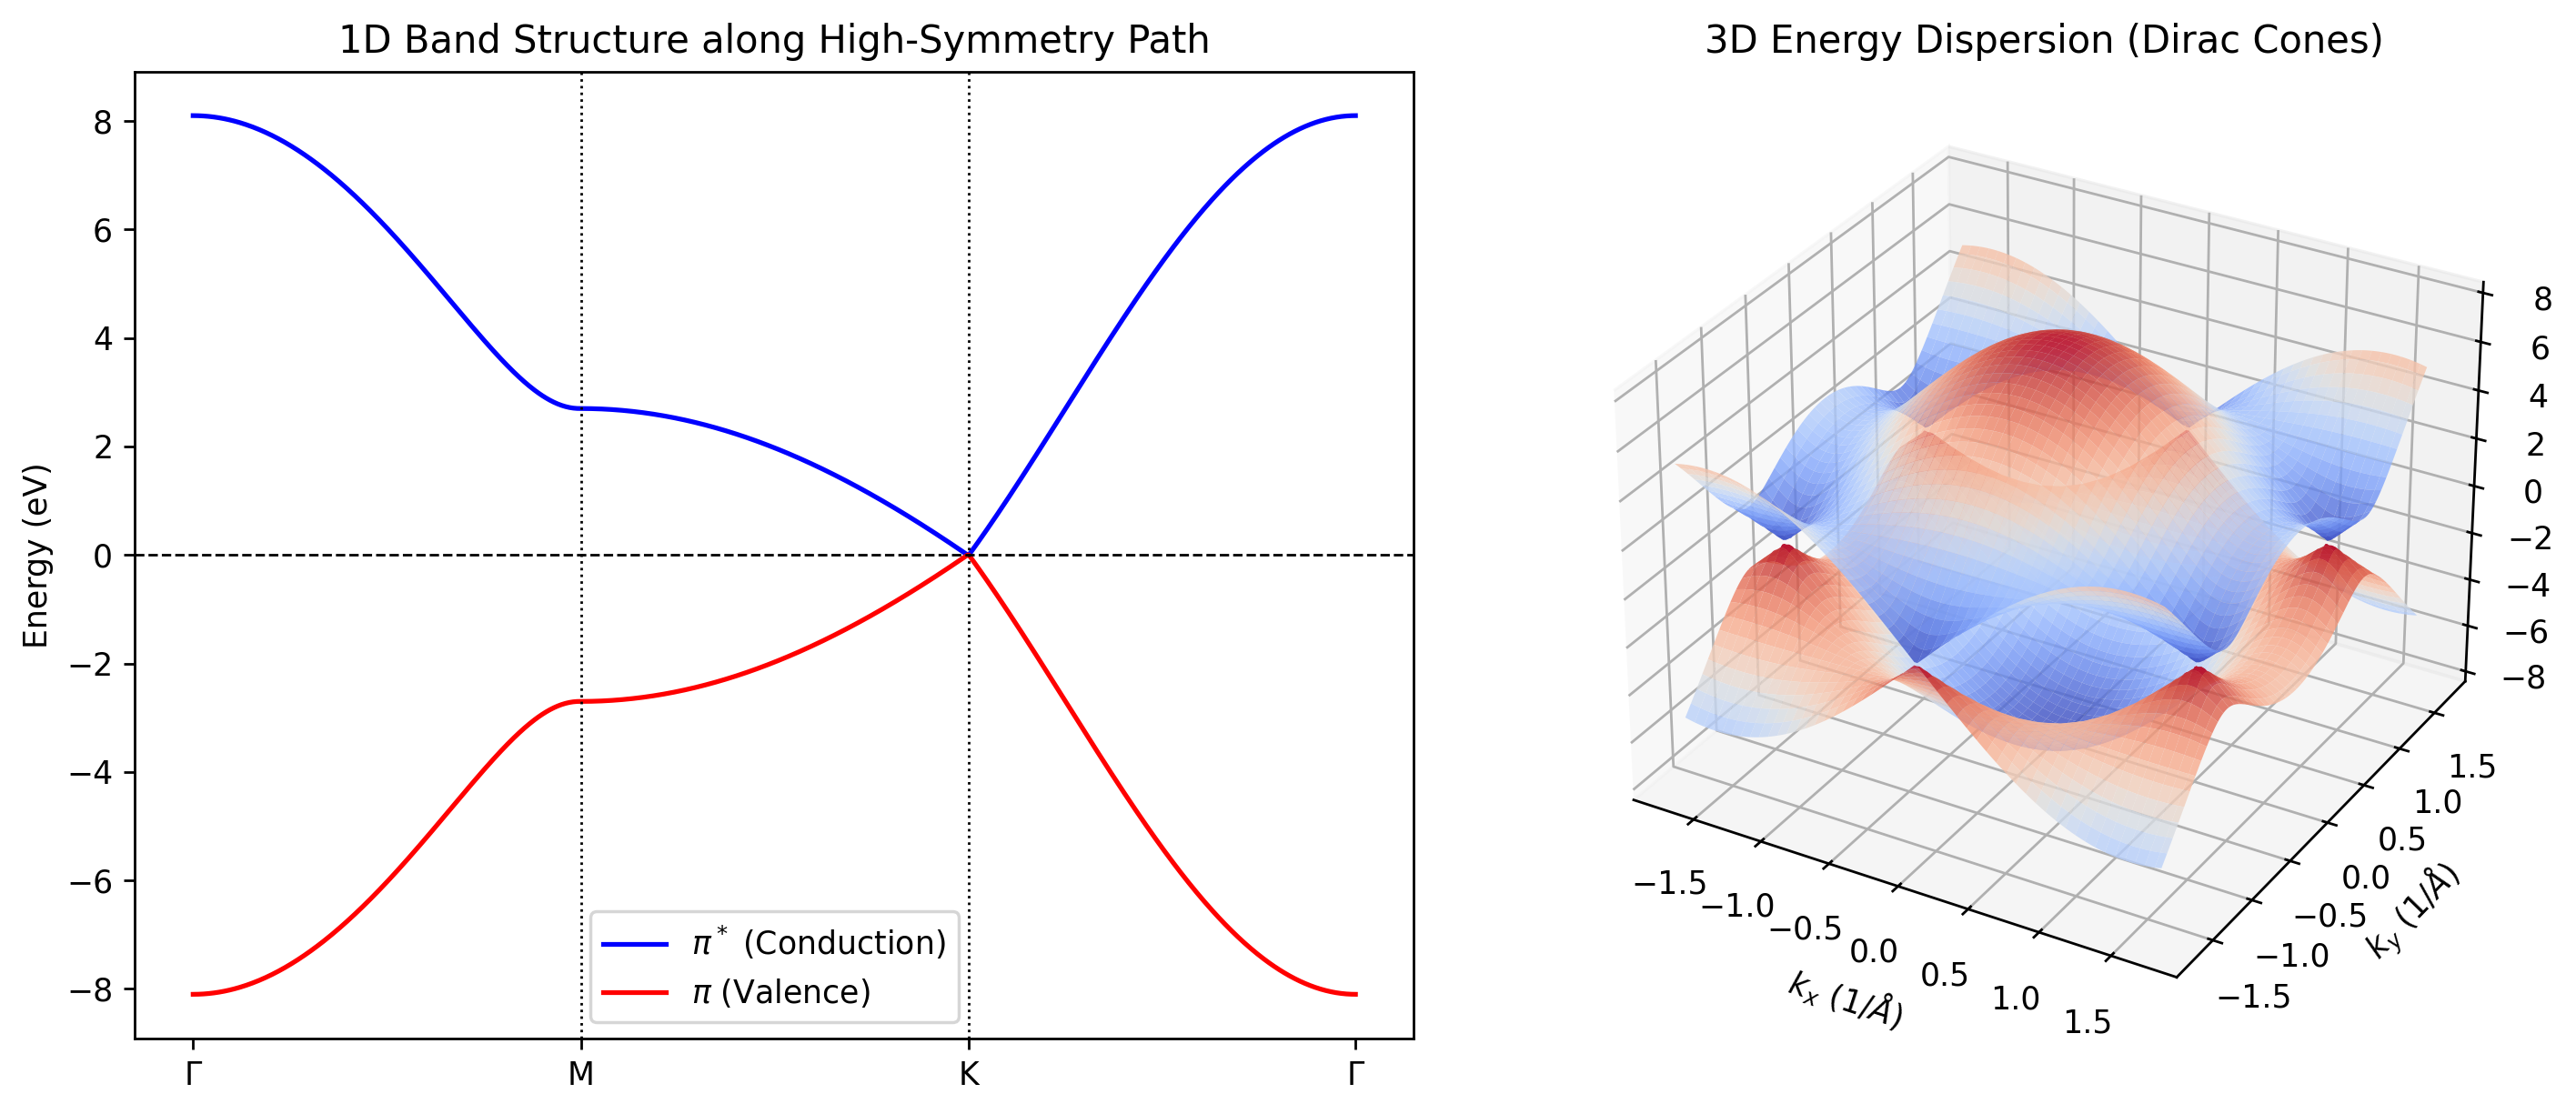

In [3]:
"""
Computes and visualizes the electronic band structure of graphene.

This module evaluates the nearest-neighbor tight-binding Hamiltonian
for a pristine 2D graphene lattice. It calculates and renders both the
1D energy dispersion along high-symmetry points in the Brillouin zone
and the 3D energy surface highlighting the Dirac cones.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# =============================================================================
# CONTROL KNOBS
# =============================================================================
T_HOPPING: float = 2.7          # eV, nearest-neighbor hopping energy
A_LATTICE: float = 2.46         # Angstroms, lattice constant
RES_1D: int = 300               # Resolution per segment for the 1D path
RES_2D: int = 150               # Resolution for the 2D surface mesh grid
PLOT_DPI: int = 250             # DPI for Colab inline rendering
# =============================================================================

# Apply rendering preferences
plt.rcParams['figure.dpi'] = PLOT_DPI

def calc_energy(k_x: np.ndarray, k_y: np.ndarray, t: float, a: float) -> np.ndarray:
    """
    Calculate the tight-binding energy dispersion for graphene.

    Args:
        k_x (np.ndarray): Wavevector array in the x-direction.
        k_y (np.ndarray): Wavevector array in the y-direction.
        t (float): Nearest-neighbor hopping energy (eV).
        a (float): Lattice constant (Angstroms).

    Returns:
        np.ndarray: Evaluated energy eigenvalues (positive conduction band).
                    The valence band is strictly the negative of this array.
    """
    term1 = 4 * np.cos(np.sqrt(3) * k_x * a / 2) * np.cos(k_y * a / 2)
    term2 = 4 * np.cos(k_y * a / 2)**2

    # Calculate the positive root (conduction band, pi*)
    energy = t * np.sqrt(1 + term1 + term2)
    return energy

def render_band_structure() -> None:
    """
    Generate and render the 1D and 3D band structure plots.
    """
    fig = plt.figure(figsize=(12, 5))

    # ---------------------------------------------------------
    # 1. 1D High-Symmetry Path (Gamma -> M -> K -> Gamma)
    # ---------------------------------------------------------
    ax1 = fig.add_subplot(121)

    # High symmetry point coordinates in k-space
    gamma = np.array([0.0, 0.0])
    m_point = np.array([2 * np.pi / (np.sqrt(3) * A_LATTICE), 0.0])
    k_point = np.array([2 * np.pi / (np.sqrt(3) * A_LATTICE), 2 * np.pi / (3 * A_LATTICE)])

    # Generate linear paths between points
    path_g_m = np.linspace(gamma, m_point, RES_1D)
    path_m_k = np.linspace(m_point, k_point, RES_1D)
    path_k_g = np.linspace(k_point, gamma, RES_1D)

    # Extract coordinates and compute energies
    k_path = np.vstack((path_g_m, path_m_k, path_k_g))
    e_path_conduction = calc_energy(k_path[:, 0], k_path[:, 1], T_HOPPING, A_LATTICE)
    e_path_valence = -e_path_conduction

    # Create a linear x-axis for plotting the continuous 1D path
    x_axis = np.arange(len(k_path))
    m_idx = RES_1D
    k_idx = 2 * RES_1D

    ax1.plot(x_axis, e_path_conduction, color='b', label=r'$\pi^*$ (Conduction)')
    ax1.plot(x_axis, e_path_valence, color='r', label=r'$\pi$ (Valence)')

    # Formatting the 1D plot
    ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax1.axvline(m_idx, color='k', linestyle=':', linewidth=0.8)
    ax1.axvline(k_idx, color='k', linestyle=':', linewidth=0.8)
    ax1.set_xticks([0, m_idx, k_idx, len(k_path)-1])
    ax1.set_xticklabels([r'$\Gamma$', 'M', 'K', r'$\Gamma$'])
    ax1.set_ylabel("Energy (eV)")
    ax1.set_title("1D Band Structure along High-Symmetry Path")
    ax1.legend()
    ax1.grid(False)

    # ---------------------------------------------------------
    # 2. 3D Surface Plot of the Dirac Cones
    # ---------------------------------------------------------
    ax2 = fig.add_subplot(122, projection='3d')

    # Define Brillouin zone bounds
    k_extent = 4 * np.pi / (3 * A_LATTICE)
    kx_range = np.linspace(-k_extent, k_extent, RES_2D)
    ky_range = np.linspace(-k_extent, k_extent, RES_2D)
    kx_mesh, ky_mesh = np.meshgrid(kx_range, ky_range)

    # Compute 2D energy surfaces
    e_surface_conduction = calc_energy(kx_mesh, ky_mesh, T_HOPPING, A_LATTICE)
    e_surface_valence = -e_surface_conduction

    # Render surfaces
    surf1 = ax2.plot_surface(kx_mesh, ky_mesh, e_surface_conduction,
                             cmap=cm.coolwarm, alpha=0.8, antialiased=True)
    surf2 = ax2.plot_surface(kx_mesh, ky_mesh, e_surface_valence,
                             cmap=cm.coolwarm, alpha=0.8, antialiased=True)

    # Formatting the 3D plot
    ax2.set_xlabel(r'$k_x$ (1/$\AA$)')
    ax2.set_ylabel(r'$k_y$ (1/$\AA$)')
    ax2.set_zlabel("Energy (eV)")
    ax2.set_title("3D Energy Dispersion (Dirac Cones)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_band_structure()

In [4]:
# =============================================================================
# COLAB ENVIRONMENT SETUP
# Run this cell first to provision the A100 with the correct CuPy binary.
# =============================================================================
!pip install cupy-cuda12x

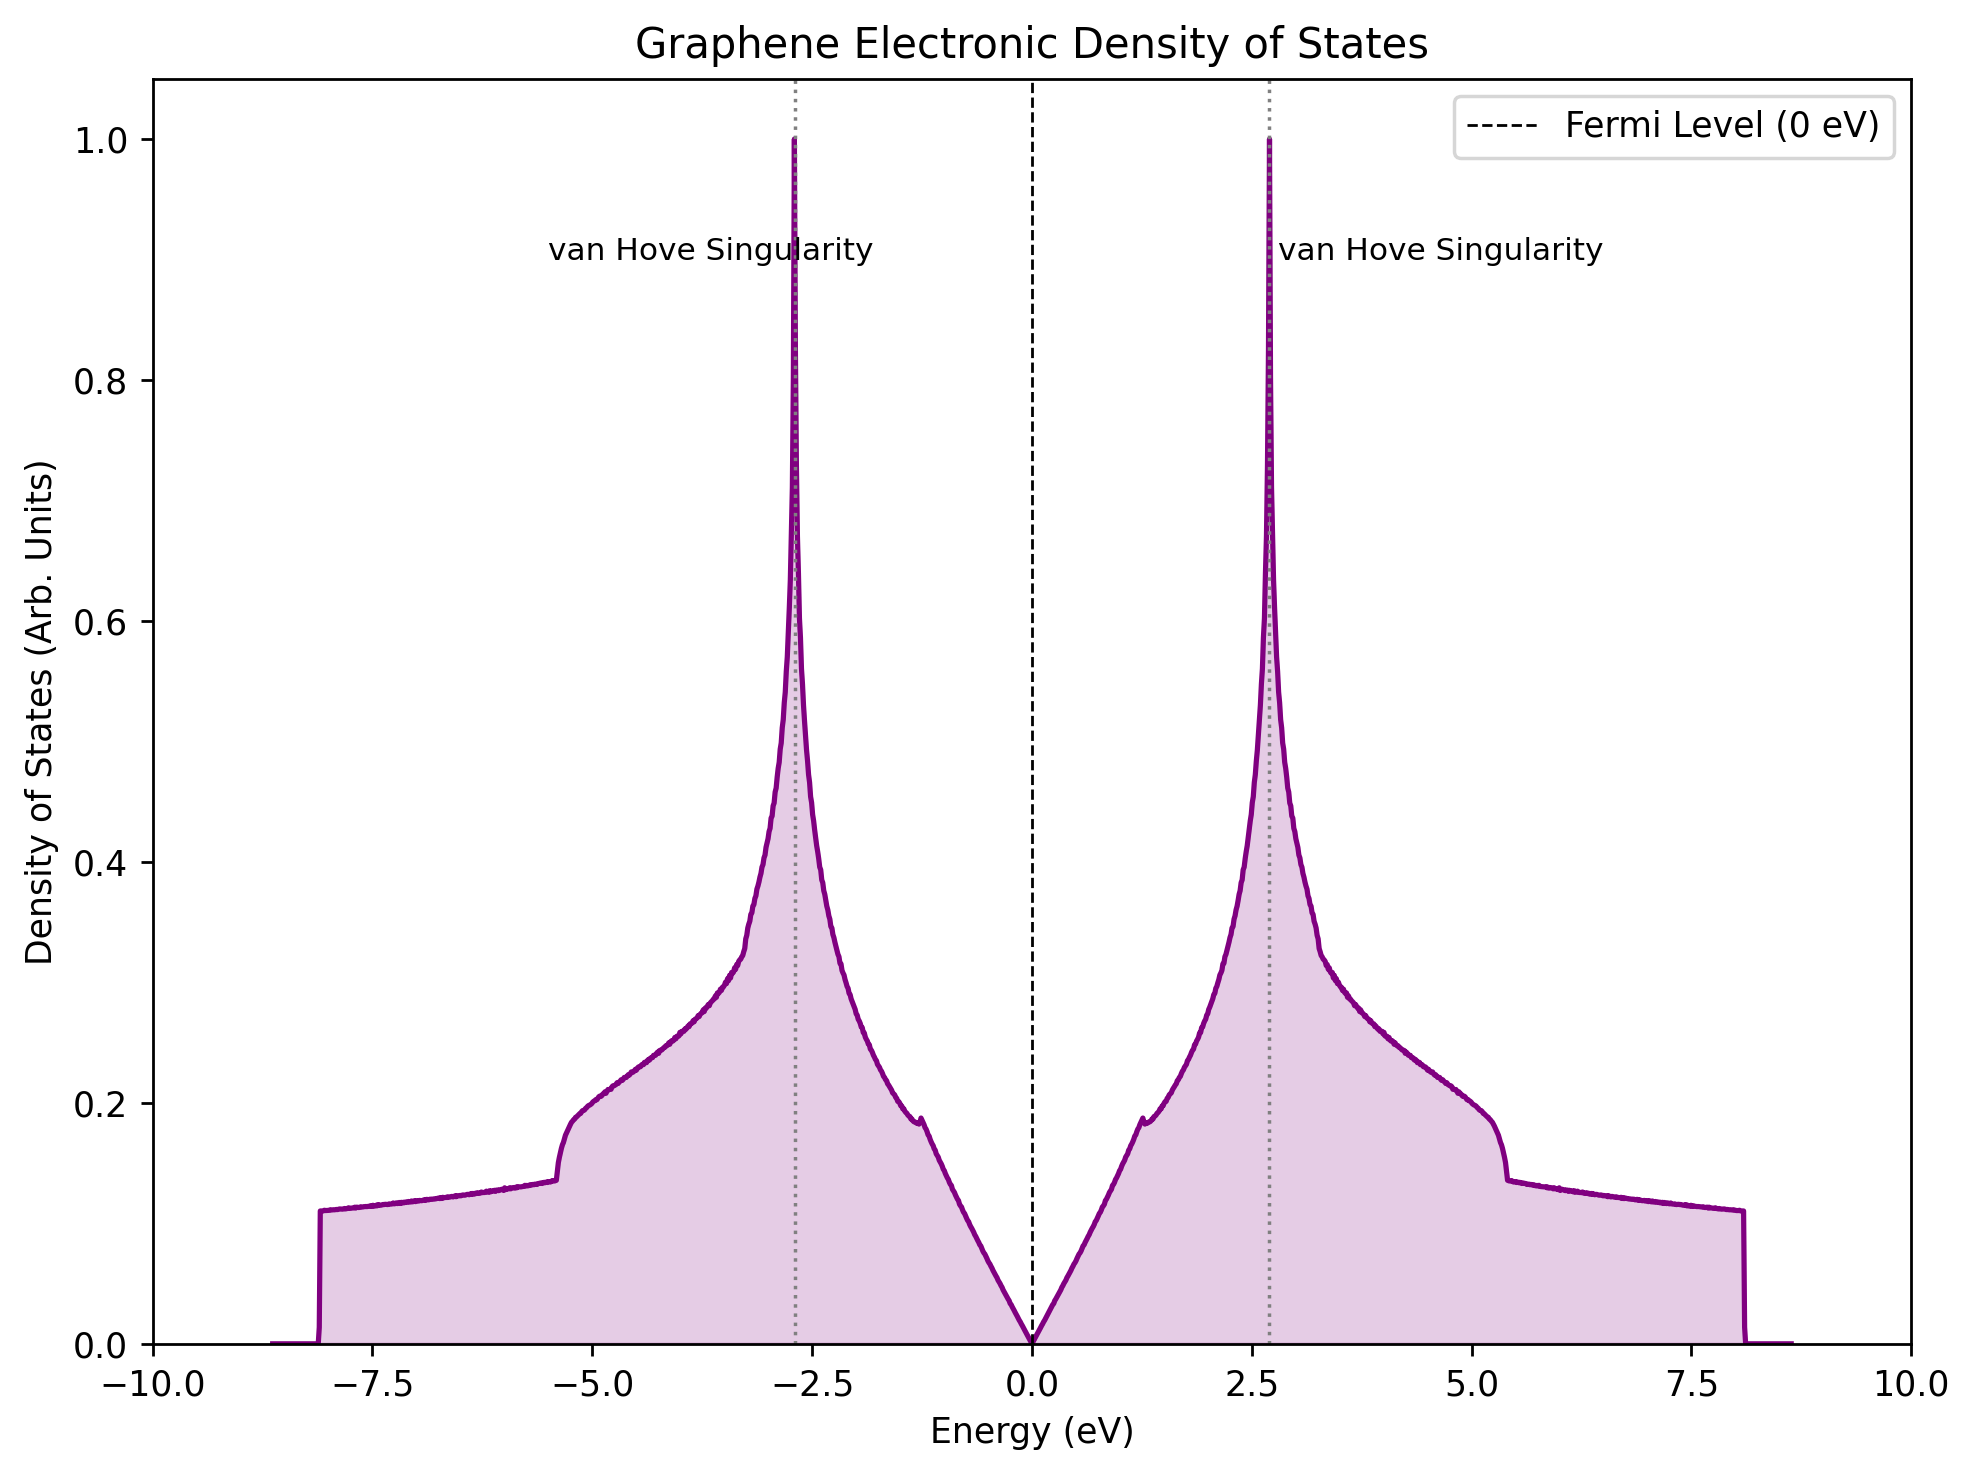

In [5]:
"""
Computes and visualizes the electronic Density of States (DOS) for graphene.

This module utilizes GPU acceleration via CuPy to evaluate the tight-binding
energy dispersion over an ultra-dense k-point mesh. It numerically integrates
the available states by computing a histogram of the energy eigenvalues,
transferring only the reduced 1D arrays back to the CPU for rendering.
"""

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONTROL KNOBS
# =============================================================================
T_HOPPING: float = 2.7          # eV, nearest-neighbor hopping energy
A_LATTICE: float = 2.46         # Angstroms, lattice constant
K_GRID_SIZE: int = 5000         # Yields 25 million k-points for extreme resolution
ENERGY_BINS: int = 1500         # Number of bins for the DOS histogram
PLOT_DPI: int = 250             # DPI for Colab inline rendering
# =============================================================================

# Apply rendering preferences
plt.rcParams['figure.dpi'] = PLOT_DPI

def compute_dos_gpu(t: float, a: float, grid_size: int, bins: int):
    """
    Calculate the Density of States using GPU acceleration.

    Args:
        t (float): Nearest-neighbor hopping energy (eV).
        a (float): Lattice constant (Angstroms).
        grid_size (int): Resolution of the 1D k-space array (total points = grid_size^2).
        bins (int): Number of energy bins for the histogram.

    Returns:
        tuple: (energy_bin_centers (np.ndarray), dos (np.ndarray)) transferred to CPU.
    """
    # Define Brillouin zone bounds
    k_extent = 4 * cp.pi / (3 * a)

    # Generate 1D arrays and create 2D meshgrid directly in VRAM
    kx = cp.linspace(-k_extent, k_extent, grid_size)
    ky = cp.linspace(-k_extent, k_extent, grid_size)
    kx_mesh, ky_mesh = cp.meshgrid(kx, ky)

    # Evaluate the tight-binding Hamiltonian on the GPU
    term1 = 4 * cp.cos(cp.sqrt(3) * kx_mesh * a / 2) * cp.cos(ky_mesh * a / 2)
    term2 = 4 * cp.cos(ky_mesh * a / 2)**2

    energy_conduction = t * cp.sqrt(1 + term1 + term2)
    energy_valence = -energy_conduction

    # Flatten arrays to compute the global histogram
    all_energies = cp.concatenate((energy_valence.flatten(), energy_conduction.flatten()))

    # Compute the histogram (DOS) entirely on the GPU
    # Energy bounds are approximately -3t to +3t for graphene
    e_max = 3.2 * t
    dos_gpu, bin_edges_gpu = cp.histogram(all_energies, bins=bins, range=(-e_max, e_max))

    # Calculate bin centers
    bin_centers_gpu = (bin_edges_gpu[:-1] + bin_edges_gpu[1:]) / 2

    # Normalize the DOS (optional, here normalized to maximum value for clean plotting)
    dos_gpu = dos_gpu / cp.max(dos_gpu)

    # Transfer the small 1D results back to host memory (CPU)
    return cp.asnumpy(bin_centers_gpu), cp.asnumpy(dos_gpu)

def render_density_of_states() -> None:
    """
    Generate and render the DOS plot.
    """
    energy_centers, dos = compute_dos_gpu(T_HOPPING, A_LATTICE, K_GRID_SIZE, ENERGY_BINS)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the DOS
    ax.plot(energy_centers, dos, color='purple', linewidth=1.5)
    ax.fill_between(energy_centers, dos, color='purple', alpha=0.2)

    # Formatting
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8, label='Fermi Level (0 eV)')
    ax.axvline(T_HOPPING, color='gray', linestyle=':', linewidth=1.0)
    ax.axvline(-T_HOPPING, color='gray', linestyle=':', linewidth=1.0)

    # Annotate van Hove singularities
    ax.text(T_HOPPING + 0.1, 0.9, 'van Hove Singularity', color='black', fontsize=9)
    ax.text(-T_HOPPING - 2.8, 0.9, 'van Hove Singularity', color='black', fontsize=9)

    ax.set_xlim([-10, 10])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Density of States (Arb. Units)")
    ax.set_title("Graphene Electronic Density of States")
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_density_of_states()

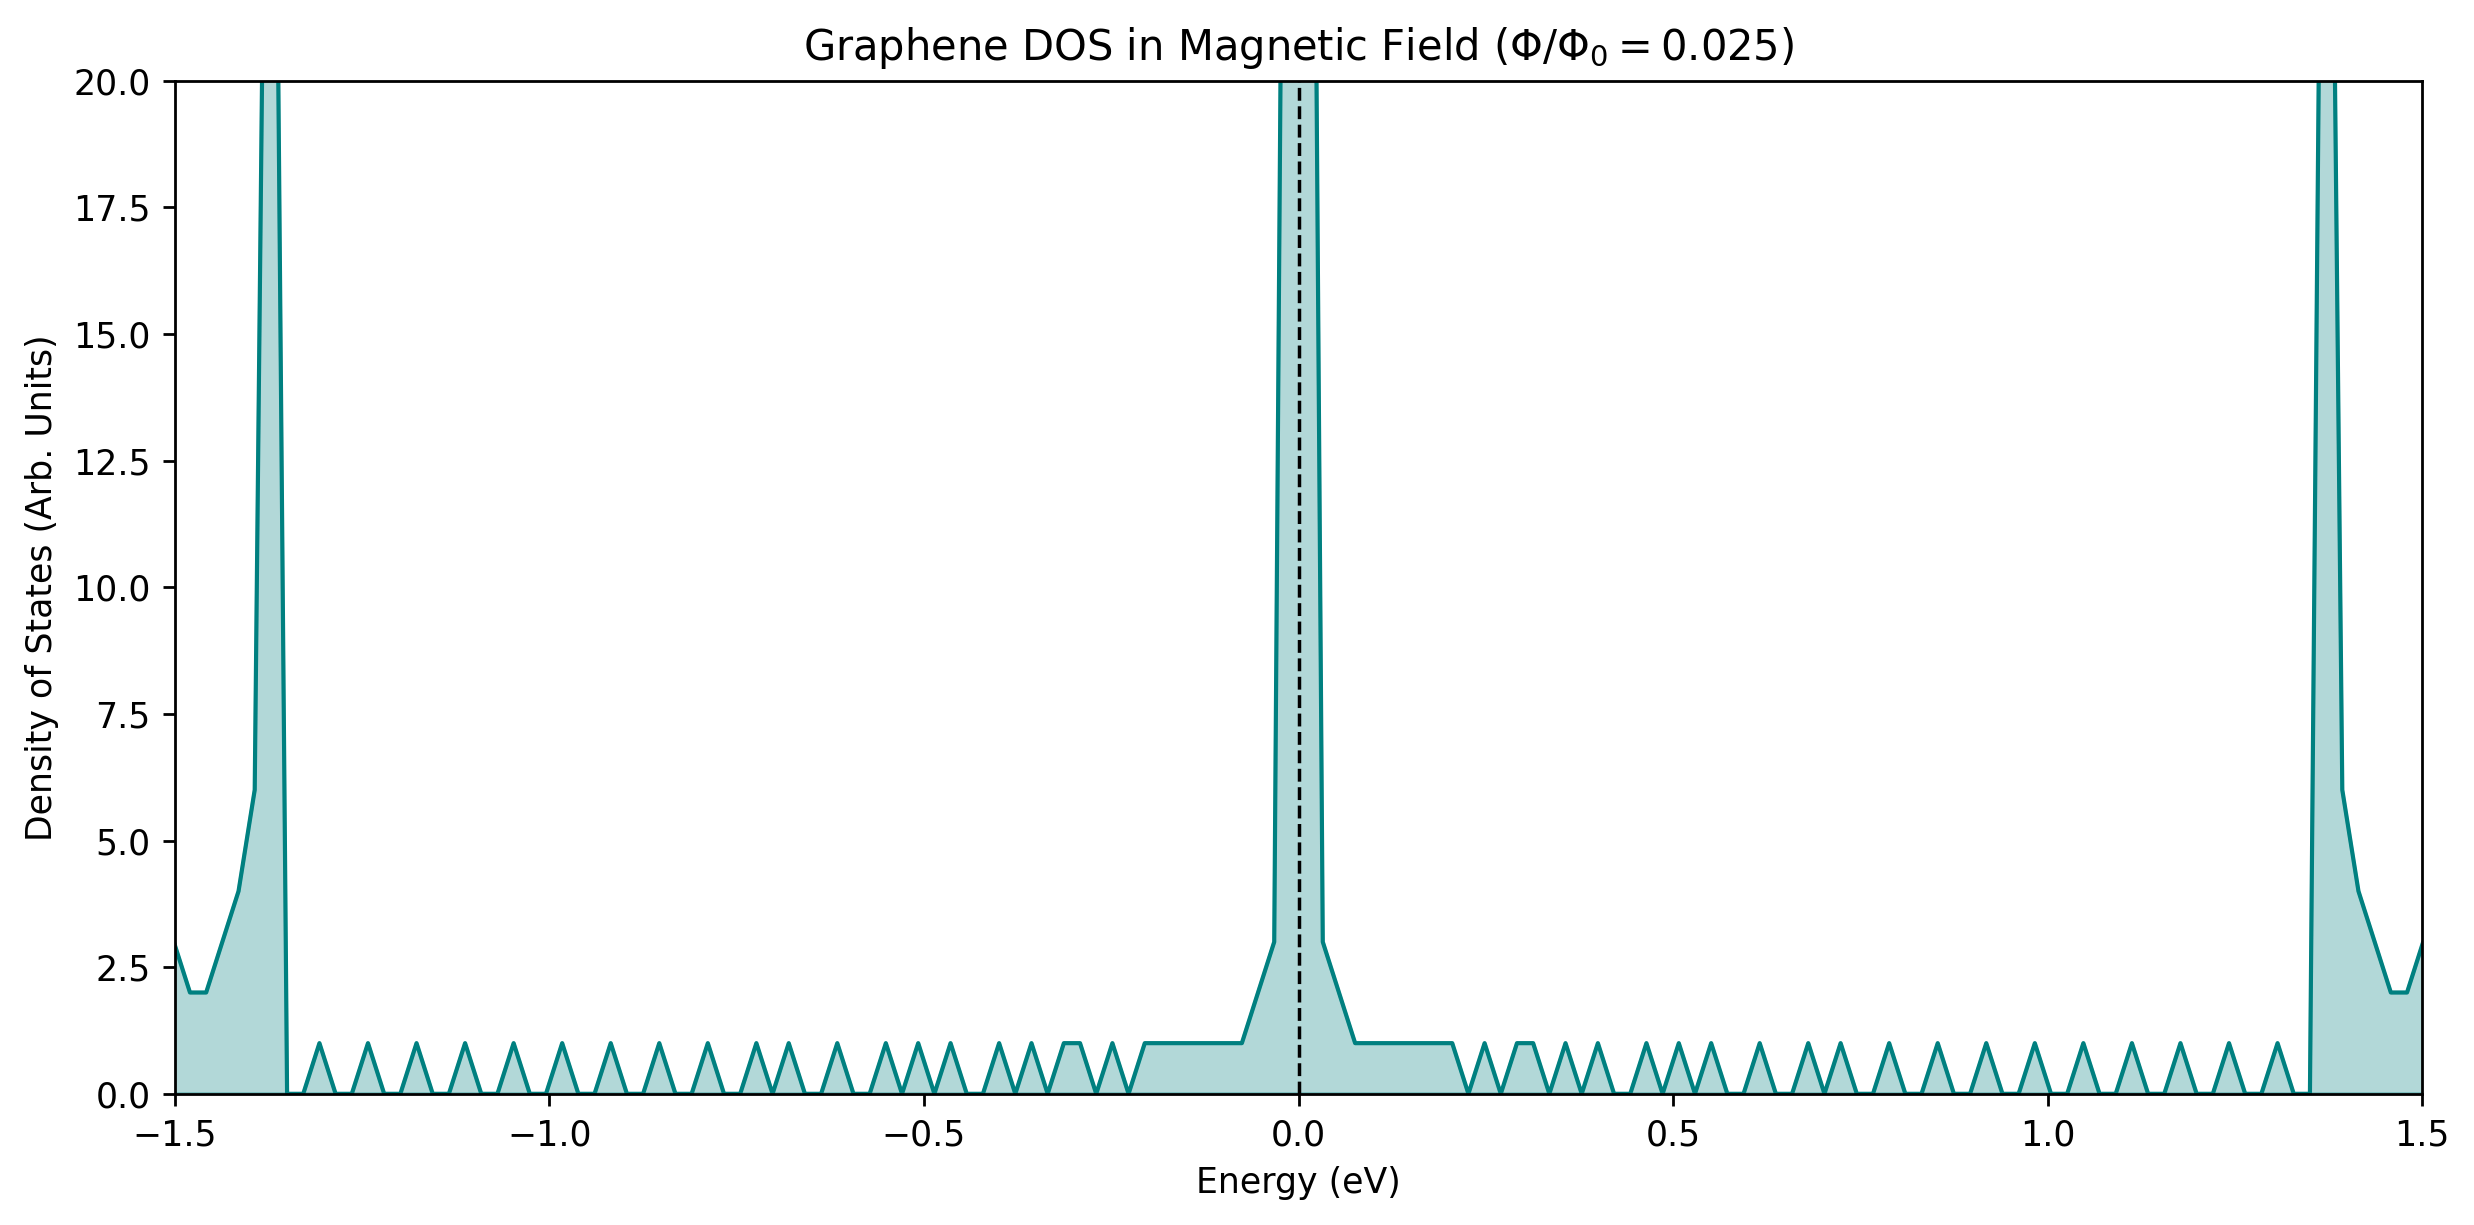

In [6]:
"""
Computes the Density of States (DOS) for a graphene flake in a magnetic field.

This module utilizes CuPy to construct a real-space tight-binding Hamiltonian
for a finite graphene lattice. It applies a Peierls substitution to model a
perpendicular magnetic field, diagonalizes the dense Hermitian matrix on the GPU,
and extracts the Landau level spectrum.
"""

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONTROL KNOBS
# =============================================================================
T_HOPPING: float = 2.7          # eV, nearest-neighbor hopping energy
A_CC: float = 1.42              # Angstroms, carbon-carbon bond length
FLAKE_W: int = 40               # Number of unit cells in the x-direction
FLAKE_H: int = 40               # Number of unit cells in the y-direction
B_FLUX_RATIO: float = 0.025     # Magnetic flux per hexagon (in units of flux quantum Phi_0)
ENERGY_BINS: int = 800          # Resolution of the DOS histogram
PLOT_DPI: int = 250             # DPI for Colab inline rendering
# =============================================================================

# Apply rendering preferences
plt.rcParams['figure.dpi'] = PLOT_DPI

def build_lattice(w: int, h: int, a_cc: float) -> tuple:
    """
    Generates the real-space coordinates for a rectangular graphene flake.
    """
    a = a_cc * np.sqrt(3)
    a1 = np.array([a, 0])
    a2 = np.array([a / 2, a * np.sqrt(3) / 2])

    basis_a = np.array([0, 0])
    basis_b = np.array([0, a_cc])

    x_coords, y_coords = [], []
    for i in range(w):
        for j in range(h):
            r = i * a1 + j * a2
            ra = r + basis_a
            rb = r + basis_b
            x_coords.extend([ra[0], rb[0]])
            y_coords.extend([ra[1], rb[1]])

    return np.array(x_coords), np.array(y_coords)

def compute_landau_levels_gpu(x: np.ndarray, y: np.ndarray, t: float, a_cc: float, flux: float, bins: int):
    """
    Constructs the Hamiltonian with Peierls substitution and diagonalizes it via CuPy.
    """
    # Transfer coordinates to GPU
    cx = cp.array(x)
    cy = cp.array(y)

    # 1. Compute the distance matrix via tensor broadcasting
    dx = cx[:, None] - cx[None, :]
    dy = cy[:, None] - cy[None, :]
    dist = cp.sqrt(dx**2 + dy**2)

    # Identify nearest neighbors (threshold slightly larger than bond length)
    is_neighbor = (dist > 0.1) & (dist < a_cc * 1.1)

    # 2. Apply Peierls Substitution
    # Landau gauge: A = (0, Bx, 0). Integral A dl simplifies to the form below.
    # We parameterize the B-field by the flux piercing a single carbon hexagon.
    area_hex = 1.5 * cp.sqrt(3) * (a_cc ** 2)

    # The phase theta_ij = (2*pi*Phi/Phi_0) * (x_i + x_j)/2 * (y_j - y_i) / Area_hex
    phase = cp.pi * flux / area_hex * (cx[:, None] + cx[None, :]) * dy

    # 3. Construct the dense Hermitian Hamiltonian
    h_matrix = cp.zeros_like(dist, dtype=cp.complex128)
    h_matrix[is_neighbor] = -t * cp.exp(1j * phase[is_neighbor])

    # 4. Diagonalize the Hamiltonian on the A100
    eigenvalues = cp.linalg.eigvalsh(h_matrix)

    # 5. Compute DOS histogram
    e_max = 3.2 * t
    dos_gpu, bin_edges_gpu = cp.histogram(eigenvalues, bins=bins, range=(-e_max, e_max))
    bin_centers_gpu = (bin_edges_gpu[:-1] + bin_edges_gpu[1:]) / 2

    # Transfer results back to CPU
    return cp.asnumpy(bin_centers_gpu), cp.asnumpy(dos_gpu)

def render_landau_dos() -> None:
    """
    Executes the calculation and plots the Landau level DOS.
    """
    # Generate flake coordinates on CPU
    x_coords, y_coords = build_lattice(FLAKE_W, FLAKE_H, A_CC)

    # Execute heavy computation on GPU
    energy_centers, dos = compute_landau_levels_gpu(
        x_coords, y_coords, T_HOPPING, A_CC, B_FLUX_RATIO, ENERGY_BINS
    )

    # Render the plot
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(energy_centers, dos, color='teal', linewidth=1.2)
    ax.fill_between(energy_centers, dos, color='teal', alpha=0.3)

    # Formatting
    ax.axvline(0, color='k', linestyle='--', linewidth=1.0)
    ax.set_xlim([-1.5, 1.5]) # Zoom in to see the low-energy LLs clearly

    # Dynamic y-limit to ignore the massive zeroth Landau level / edge state spike
    # and make the higher-order levels visible.
    mean_dos = np.mean(dos)
    ax.set_ylim([0, mean_dos * 5])

    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Density of States (Arb. Units)")
    ax.set_title(rf"Graphene DOS in Magnetic Field ($\Phi/\Phi_0 = {B_FLUX_RATIO}$)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_landau_dos()